<a href="https://colab.research.google.com/github/springboardmentor1234x-stack/CreditPath-AI/blob/Pratichee-Acharya/Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

VARIOUS MODEL TRAINING FOR COMPARISION USING SMOTE FEATURE ENGINEERING AND REMOVING LEAKY FEATURES

Synthetic Features + scale_pos_weight
Preprocessing & Feature Engineering
Adding derived features (Batches 1, 2, 3)...
Final processed shape: (38480, 99)
emp_length              993
revol_util               59
last_pymnt_d             71
next_pymnt_d          35097
last_credit_pull_d        3
dtype: int64
--- Starting Hyperparameter Tuning (XGBoost) ---
Using scale_pos_weight: 5.60
Fitting XGBoost...
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:01:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost Parameters: {'subsample': 0.8, 'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.8}
Best XGBoost CV AUC: 0.7075

Final Model Evaluation (Test Set)

**Final XGBoost AUC: 0.7104**
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.64      0.75      6530
           1       0.24      0.65      0.36      1166

    accuracy                           0.64      7696
   macro avg       0.58      0.65      0.55      7696
weighted avg       0.81      0.64      0.69      7696


Generating Feature Importance Plot


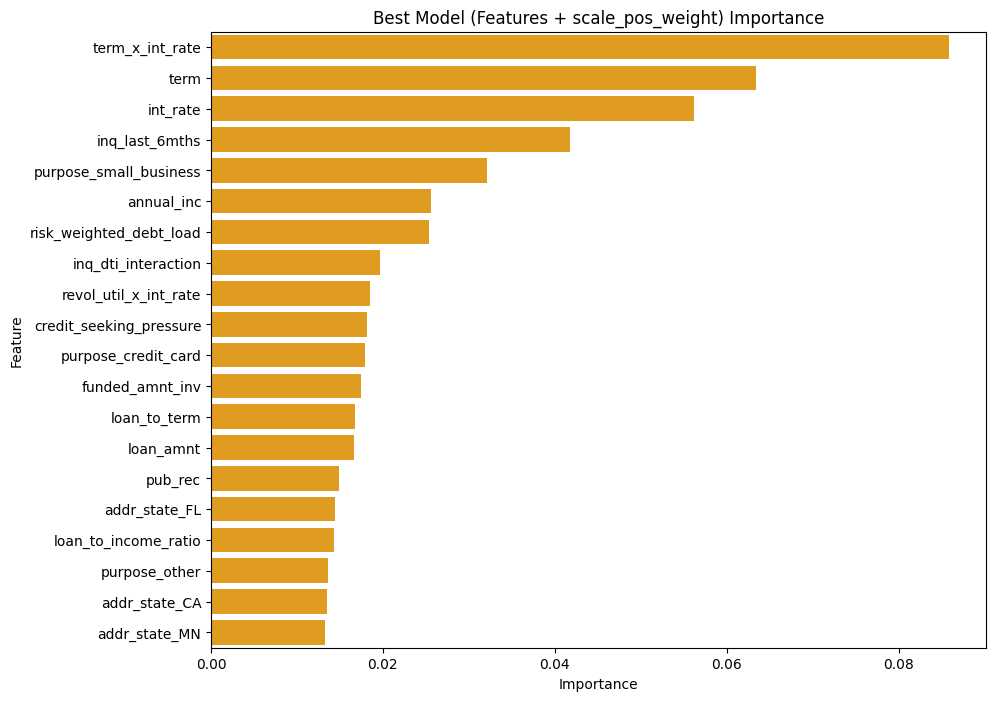

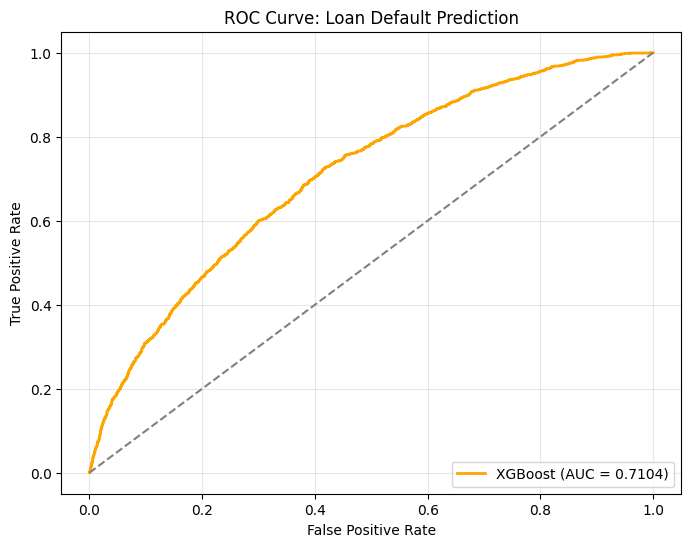

In [2]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

print("Synthetic Features + scale_pos_weight")

#1. Load Data
df = pd.read_csv("Anonymize_Loan_Default_data.csv", encoding="latin1")

#2. Define Target and Fix Leaks
target = 'repay_fail'
y = df[target]
leaky_features = [
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'last_pymnt_amnt', 'last_pymnt_d',
    'loan_status'
]
cols_to_drop = [
    'Unnamed: 0', 'id', 'member_id', 'next_pymnt_d',
    'zip_code', 'issue_d',
    'last_credit_pull_d', 'earliest_cr_line'
] + leaky_features

all_cols_to_drop = [col for col in cols_to_drop if col in df.columns] + [target]
X = df.drop(columns=all_cols_to_drop)

#3. Feature Engineering & Cleaning (Batches 1-3)
print("Preprocessing & Feature Engineering")
threshold = 0.4 * len(X)
X = X.dropna(thresh=threshold, axis=1)
X['term'] = X['term'].str.replace(' months', '').astype(float)
X['revol_util'] = X['revol_util'].astype(str).str.replace(r'[“%”]', '', regex=True).str.strip()
X['revol_util'] = pd.to_numeric(X['revol_util'], errors='coerce')
def clean_emp_length(text):
    if pd.isnull(text) or text == 'n/a': return np.nan
    if '< 1 year' in text: return 0.5
    if '10+ years' in text: return 10
    match = re.search(r'(\d+)', text)
    if match: return float(match.group(1))
    return np.nan
X['emp_length'] = X['emp_length'].apply(clean_emp_length)

print("Adding derived features (Batches 1, 2, 3)...")
earliest_cr_line_dt = pd.to_datetime(df['earliest_cr_line'], format='%b-%y', errors='coerce')
issue_d_dt = pd.to_datetime(df['issue_d'], format='%b-%y', errors='coerce')
X['credit_history_length_months'] = (issue_d_dt.dt.year * 12 + issue_d_dt.dt.month) - \
                                    (earliest_cr_line_dt.dt.year * 12 + earliest_cr_line_dt.dt.month)
X['credit_history_length_months'] = X['credit_history_length_months'].replace(0, 1)
X['annual_inc'] = X['annual_inc'].replace(0, np.nan)
X['loan_to_income_ratio'] = X['loan_amnt'] / X['annual_inc']
X['revol_bal_per_acc'] = np.where(X['open_acc'] > 0, X['revol_bal'] / X['open_acc'], 0)
X['acc_open_freq'] = np.where(X['credit_history_length_months'] > 0,
                              X['total_acc'] / X['credit_history_length_months'], 0)
X['loan_to_term'] = X['loan_amnt'] / X['term']
X['dti_x_int_rate'] = X['dti'] * X['int_rate']
X['inq_dti_interaction'] = X['inq_last_6mths'] * X['dti']
X['term_x_int_rate'] = X['term'] * X['int_rate']
X['acc_utilization'] = np.where(X['total_acc'] > 0, X['open_acc'] / X['total_acc'], 0)
X['loan_burden_ratio'] = X['installment'] / (X['annual_inc'] + 1e-6)
X['risk_weighted_debt_load'] = (X['dti'] * X['int_rate']) / (X['annual_inc'] + 1e-6)
X['credit_seeking_pressure'] = X['inq_last_6mths'] * X['acc_utilization']
X['revol_util_x_int_rate'] = X['revol_util'] * X['int_rate']

#4. Preprocessing
if 'revol_util' in X.columns:
    X['revol_util'] = X['revol_util'].fillna(X['revol_util'].mode()[0])
if 'revol_bal' in X.columns:
    X['revol_bal'] = X['revol_bal'].fillna(X['revol_bal'].median())

X = pd.get_dummies(X, drop_first=True)

numerical_features=['loan_amnt','annual_inc','dti','revol_bal',
                    'loan_to_income_ratio', 'revol_bal_per_acc', 'acc_open_freq',
                    'loan_to_term', 'dti_x_int_rate', 'loan_burden_ratio',
                    'risk_weighted_debt_load', 'credit_seeking_pressure', 'revol_util_x_int_rate']
cols_to_scale = [col for col in numerical_features if col in X.columns]
if cols_to_scale:
    scaler = StandardScaler()
    X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

X = X.fillna(X.median())
print(f"Final processed shape: {X.shape}")
df = df.fillna(df.median(numeric_only=True))
print(df.isnull().sum()[df.isnull().sum() > 0])
#5. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

#6. Hyperparameter Tuning (XGBoost)
print("--- Starting Hyperparameter Tuning (XGBoost) ---")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Using scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(eval_metric='logloss',
                          random_state=42,
                          scale_pos_weight=scale_pos_weight,
                          use_label_encoder=False)
param_grid = {
    'n_estimators': [200, 250], 'max_depth': [3, 4], 'learning_rate': [0.05],
    'gamma': [0.2], 'subsample': [0.8], 'colsample_bytree': [0.8]
}
xgb_search = RandomizedSearchCV(
    estimator=xgb_model, param_distributions=param_grid,
    n_iter=4, scoring='roc_auc', cv=3, verbose=1, n_jobs=-1, random_state=42
)
print("Fitting XGBoost...")
xgb_search.fit(X_train, y_train)
print("Best XGBoost Parameters:", xgb_search.best_params_)
print(f"Best XGBoost CV AUC: {xgb_search.best_score_:.4f}")

#7. Final Evaluation
print("\nFinal Model Evaluation (Test Set)")
best_xgb = xgb_search.best_estimator_
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]
y_pred_xgb = best_xgb.predict(X_test)
final_auc = roc_auc_score(y_test, y_prob_xgb)
print(f"\n**Final XGBoost AUC: {final_auc:.4f}**")
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))

#8. Feature Importance
print("\nGenerating Feature Importance Plot")
importances = best_xgb.feature_importances_
features = X_train.columns
imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False).head(20)
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=imp_df, color='orange')
plt.title('Best Model (Features + scale_pos_weight) Importance')
plt.savefig('best_model_importance.png', bbox_inches='tight')
plt.show()

from sklearn.metrics import roc_curve

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'XGBoost (AUC = {final_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Loan Default Prediction')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

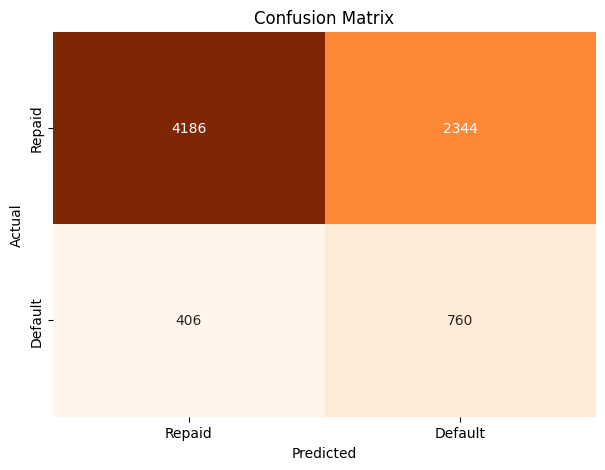

In [6]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Repaid', 'Default'],
            yticklabels=['Repaid', 'Default'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

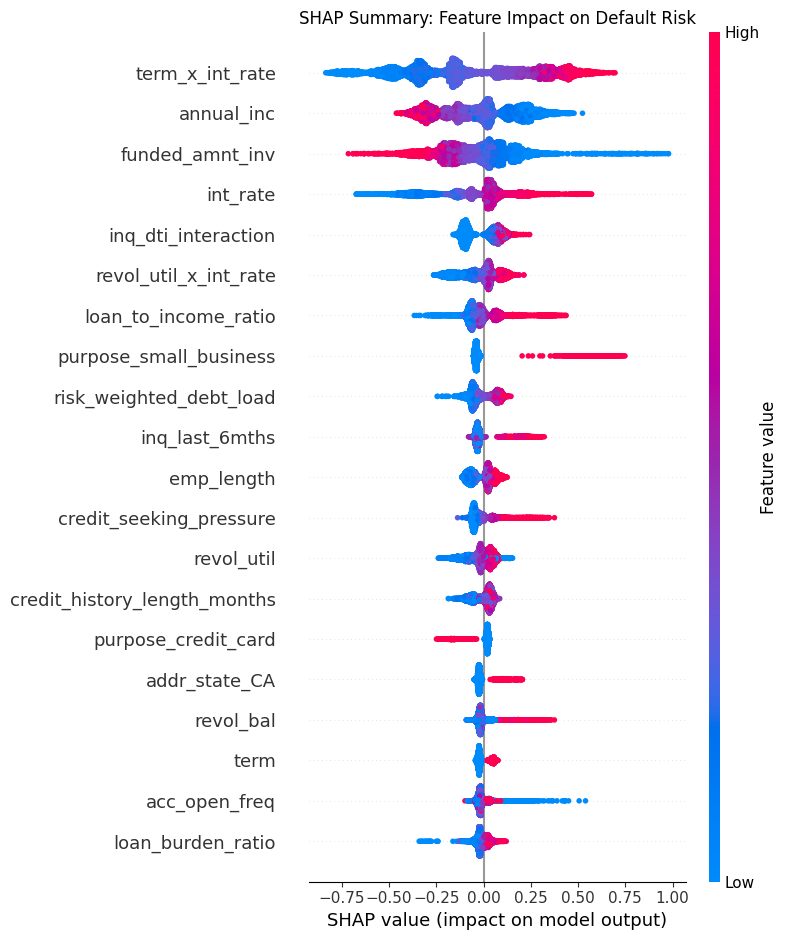

In [7]:
!pip install shap
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Plot summary
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary: Feature Impact on Default Risk")
shap.summary_plot(shap_values, X_test, show=False, color='orange')
plt.show()

Synthetic Features + SMOTE
Starting Preprocessing & Feature Engineering
Adding derived features (Batches 1, 2, 3)...
Final processed shape: (38480, 99)
Starting Hyperparameter Tuning (XGBoost + SMOTE)
Fitting SMOTE pipeline...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:05:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best SMOTE Pipeline Parameters: {'model__subsample': 1.0, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Best SMOTE Pipeline CV AUC: 0.6898

 Final Model Evaluation (Test Set)

**Final XGBoost + SMOTE AUC: 0.6898**
XGBoost + SMOTE Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.99      0.92      6530
           1       0.43      0.04      0.08      1166

    accuracy                           0.85      7696
   macro avg       0.64      0.52      0.50      7696
weighted avg       0.79      0.85      0.79      7696


Generating Feature Importance Plot


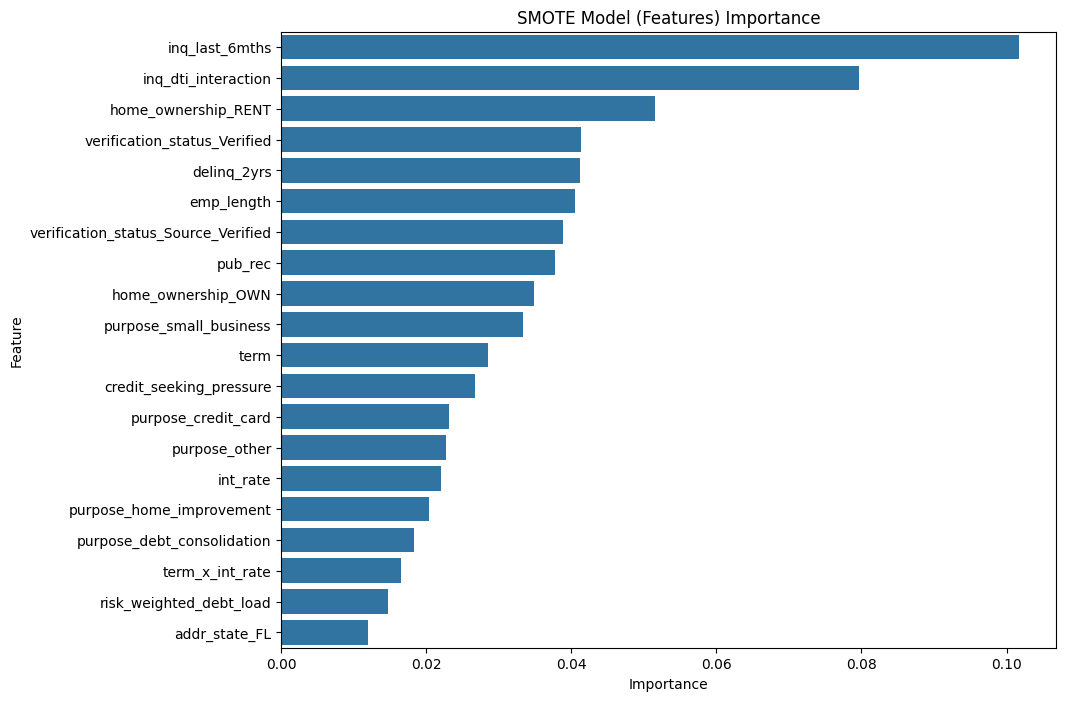

In [8]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("Synthetic Features + SMOTE")

#1. Load Data
df = pd.read_csv("Anonymize_Loan_Default_data.csv", encoding="latin1")

#2. Define Target and Fix Leaks
target = 'repay_fail'
y = df[target]
leaky_features = [
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'last_pymnt_amnt', 'last_pymnt_d',
    'loan_status'
]
cols_to_drop = [
    'Unnamed: 0', 'id', 'member_id', 'next_pymnt_d',
    'zip_code', 'issue_d',
    'last_credit_pull_d', 'earliest_cr_line'
] + leaky_features

all_cols_to_drop = [col for col in cols_to_drop if col in df.columns] + [target]
X = df.drop(columns=all_cols_to_drop)

#3. Feature Engineering & Cleaning (Batches 1-3)
print("Starting Preprocessing & Feature Engineering")
threshold = 0.4 * len(X)
X = X.dropna(thresh=threshold, axis=1)
X['term'] = X['term'].str.replace(' months', '').astype(float)
X['revol_util'] = X['revol_util'].astype(str).str.replace(r'[“%”]', '', regex=True).str.strip()
X['revol_util'] = pd.to_numeric(X['revol_util'], errors='coerce')
def clean_emp_length(text):
    if pd.isnull(text) or text == 'n/a': return np.nan
    if '< 1 year' in text: return 0.5
    if '10+ years' in text: return 10
    match = re.search(r'(\d+)', text)
    if match: return float(match.group(1))
    return np.nan
X['emp_length'] = X['emp_length'].apply(clean_emp_length)

print("Adding derived features (Batches 1, 2, 3)...")
earliest_cr_line_dt = pd.to_datetime(df['earliest_cr_line'], format='%b-%y', errors='coerce')
issue_d_dt = pd.to_datetime(df['issue_d'], format='%b-%y', errors='coerce')
X['credit_history_length_months'] = (issue_d_dt.dt.year * 12 + issue_d_dt.dt.month) - \
                                    (earliest_cr_line_dt.dt.year * 12 + earliest_cr_line_dt.dt.month)
X['credit_history_length_months'] = X['credit_history_length_months'].replace(0, 1)
X['annual_inc'] = X['annual_inc'].replace(0, np.nan)
X['loan_to_income_ratio'] = X['loan_amnt'] / X['annual_inc']
X['revol_bal_per_acc'] = np.where(X['open_acc'] > 0, X['revol_bal'] / X['open_acc'], 0)
X['acc_open_freq'] = np.where(X['credit_history_length_months'] > 0,
                              X['total_acc'] / X['credit_history_length_months'], 0)
X['loan_to_term'] = X['loan_amnt'] / X['term']
X['dti_x_int_rate'] = X['dti'] * X['int_rate']
X['inq_dti_interaction'] = X['inq_last_6mths'] * X['dti']
X['term_x_int_rate'] = X['term'] * X['int_rate']
X['acc_utilization'] = np.where(X['total_acc'] > 0, X['open_acc'] / X['total_acc'], 0)
X['loan_burden_ratio'] = X['installment'] / (X['annual_inc'] + 1e-6)
X['risk_weighted_debt_load'] = (X['dti'] * X['int_rate']) / (X['annual_inc'] + 1e-6)
X['credit_seeking_pressure'] = X['inq_last_6mths'] * X['acc_utilization']
X['revol_util_x_int_rate'] = X['revol_util'] * X['int_rate']

#4. Preprocessing
if 'revol_util' in X.columns:
    X['revol_util'] = X['revol_util'].fillna(X['revol_util'].mode()[0])
if 'revol_bal' in X.columns:
    X['revol_bal'] = X['revol_bal'].fillna(X['revol_bal'].median())

X = pd.get_dummies(X, drop_first=True)

numerical_features=['loan_amnt','annual_inc','dti','revol_bal',
                    'loan_to_income_ratio', 'revol_bal_per_acc', 'acc_open_freq',
                    'loan_to_term', 'dti_x_int_rate', 'loan_burden_ratio',
                    'risk_weighted_debt_load', 'credit_seeking_pressure', 'revol_util_x_int_rate']
cols_to_scale = [col for col in numerical_features if col in X.columns]
if cols_to_scale:
    scaler = StandardScaler()
    X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

X = X.fillna(X.median())
print(f"Final processed shape: {X.shape}")

#5. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

#6. Hyperparameter Tuning (with SMOTE Pipeline)
print("Starting Hyperparameter Tuning (XGBoost + SMOTE)")

xgb_model = XGBClassifier(eval_metric='logloss',
                          random_state=42,
                          use_label_encoder=False)

# Create the pipeline
smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb_model)
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

smote_search = RandomizedSearchCV(
    estimator=smote_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring='roc_auc', cv=3, verbose=1, n_jobs=-1, random_state=42
)
print("Fitting SMOTE pipeline...")
smote_search.fit(X_train, y_train)
print("Best SMOTE Pipeline Parameters:", smote_search.best_params_)
print(f"Best SMOTE Pipeline CV AUC: {smote_search.best_score_:.4f}")

#7. Final Evaluation
print("\n Final Model Evaluation (Test Set)")
best_smote_model = smote_search.best_estimator_
y_prob_xgb = best_smote_model.predict_proba(X_test)[:,1]
y_pred_xgb = best_smote_model.predict(X_test)
final_auc = roc_auc_score(y_test, y_prob_xgb)
print(f"\n**Final XGBoost + SMOTE AUC: {final_auc:.4f}**")
print("XGBoost + SMOTE Classification Report:\n", classification_report(y_test, y_pred_xgb))

#8. Feature Importance
print("\nGenerating Feature Importance Plot")
final_model_from_pipeline = best_smote_model.named_steps['model']
importances = final_model_from_pipeline.feature_importances_
features = X_train.columns
imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False).head(20)
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=imp_df)
plt.title('SMOTE Model (Features) Importance')
plt.savefig('smote_model_importance.png', bbox_inches='tight')
plt.show()

LightGBM + Features + is_unbalance=True
 Starting Preprocessing & Feature Engineering 
Adding derived features (Batches 1, 2, 3)...
Final processed shape: (38480, 99)
Starting Hyperparameter Tuning (LightGBM)
Using is_unbalance=True
Fitting LightGBM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Number of positive: 4663, number of negative: 26121
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012082 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5822
[LightGBM] [Info] Number of data points in the train set: 30784, number of used features: 91
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.151475 -> initscore=-1.723081
[LightGBM] [Info] Start training from score -1.723081
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

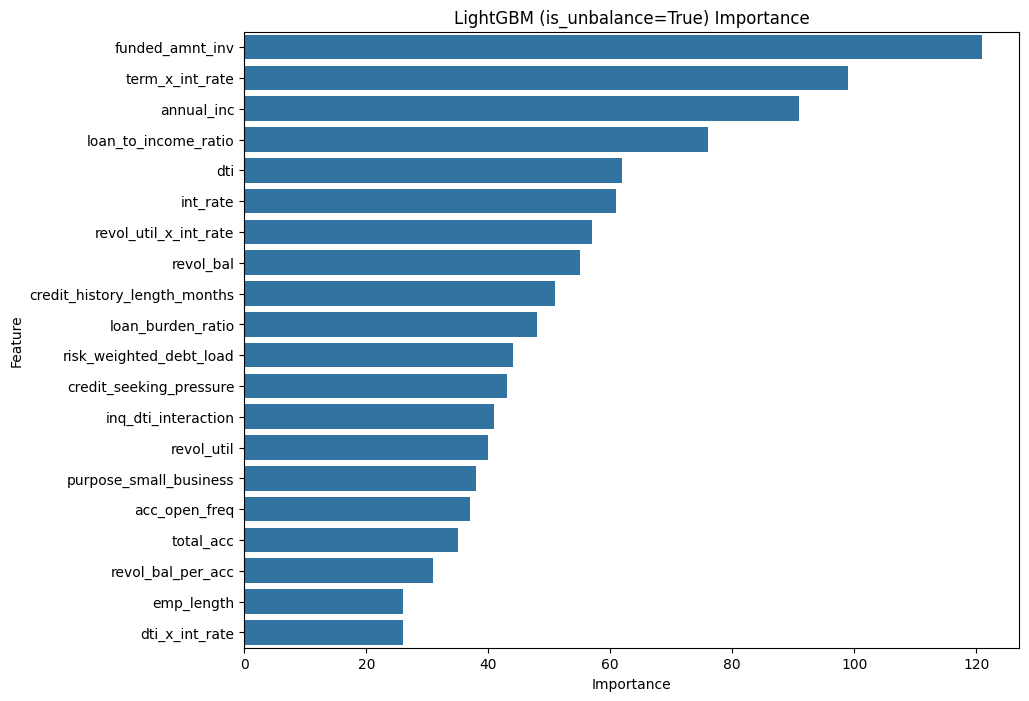

In [9]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns

print("LightGBM + Features + is_unbalance=True")

# 1. Load Data
df = pd.read_csv("Anonymize_Loan_Default_data.csv", encoding="latin1")

# 2. Define Target and Fix Leaks
target = 'repay_fail'
y = df[target]
leaky_features = [
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'last_pymnt_amnt', 'last_pymnt_d',
    'loan_status'
]
cols_to_drop = [
    'Unnamed: 0', 'id', 'member_id', 'next_pymnt_d',
    'zip_code', 'issue_d',
    'last_credit_pull_d', 'earliest_cr_line'
] + leaky_features
all_cols_to_drop = [col for col in cols_to_drop if col in df.columns] + [target]
X = df.drop(columns=all_cols_to_drop)

# 3. Feature Engineering & Cleaning (Batches 1-3)
print(" Starting Preprocessing & Feature Engineering ")
threshold = 0.4 * len(X)
X = X.dropna(thresh=threshold, axis=1)
X['term'] = X['term'].str.replace(' months', '').astype(float)
X['revol_util'] = X['revol_util'].astype(str).str.replace(r'[“%”]', '', regex=True).str.strip()
X['revol_util'] = pd.to_numeric(X['revol_util'], errors='coerce')
def clean_emp_length(text):
    if pd.isnull(text) or text == 'n/a': return np.nan
    if '< 1 year' in text: return 0.5
    if '10+ years' in text: return 10
    match = re.search(r'(\d+)', text)
    if match: return float(match.group(1))
    return np.nan
X['emp_length'] = X['emp_length'].apply(clean_emp_length)

print("Adding derived features (Batches 1, 2, 3)...")
earliest_cr_line_dt = pd.to_datetime(df['earliest_cr_line'], format='%b-%y', errors='coerce')
issue_d_dt = pd.to_datetime(df['issue_d'], format='%b-%y', errors='coerce')
X['credit_history_length_months'] = (issue_d_dt.dt.year * 12 + issue_d_dt.dt.month) - \
                                    (earliest_cr_line_dt.dt.year * 12 + earliest_cr_line_dt.dt.month)
X['credit_history_length_months'] = X['credit_history_length_months'].replace(0, 1)
X['annual_inc'] = X['annual_inc'].replace(0, np.nan)
X['loan_to_income_ratio'] = X['loan_amnt'] / X['annual_inc']
X['revol_bal_per_acc'] = np.where(X['open_acc'] > 0, X['revol_bal'] / X['open_acc'], 0)
X['acc_open_freq'] = np.where(X['credit_history_length_months'] > 0,
                              X['total_acc'] / X['credit_history_length_months'], 0)
X['loan_to_term'] = X['loan_amnt'] / X['term']
X['dti_x_int_rate'] = X['dti'] * X['int_rate']
X['inq_dti_interaction'] = X['inq_last_6mths'] * X['dti']
X['term_x_int_rate'] = X['term'] * X['int_rate']
X['acc_utilization'] = np.where(X['total_acc'] > 0, X['open_acc'] / X['total_acc'], 0)
X['loan_burden_ratio'] = X['installment'] / (X['annual_inc'] + 1e-6)
X['risk_weighted_debt_load'] = (X['dti'] * X['int_rate']) / (X['annual_inc'] + 1e-6)
X['credit_seeking_pressure'] = X['inq_last_6mths'] * X['acc_utilization']
X['revol_util_x_int_rate'] = X['revol_util'] * X['int_rate']

#4. Preprocessing
if 'revol_util' in X.columns:
    X['revol_util'] = X['revol_util'].fillna(X['revol_util'].mode()[0])
if 'revol_bal' in X.columns:
    X['revol_bal'] = X['revol_bal'].fillna(X['revol_bal'].median())
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(X.median())
print(f"Final processed shape: {X.shape}")

#5. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

#6. Hyperparameter Tuning (LightGBM)
print("Starting Hyperparameter Tuning (LightGBM)")
print("Using is_unbalance=True")

lgbm_model = LGBMClassifier(random_state=42,
                            is_unbalance=True,
                            n_jobs=-1)
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'num_leaves': [15, 31, 50],
}
lgbm_search = RandomizedSearchCV(
    estimator=lgbm_model, param_distributions=param_grid,
    n_iter=10, scoring='roc_auc', cv=3, verbose=1, n_jobs=-1, random_state=42
)
print("Fitting LightGBM...")
lgbm_search.fit(X_train, y_train)
print("Best LightGBM Parameters:", lgbm_search.best_params_)
print(f"Best LightGBM CV AUC: {lgbm_search.best_score_:.4f}")

#7. Final Evaluation
print("\nFinal Model Evaluation (Test Set)")
best_lgbm = lgbm_search.best_estimator_
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:,1]
y_pred_lgbm = best_lgbm.predict(X_test)
final_auc = roc_auc_score(y_test, y_prob_lgbm)
print(f"\n**Final LightGBM AUC: {final_auc:.4f}**")
print("LightGBM Classification Report:\n", classification_report(y_test, y_pred_lgbm))

# 8. Feature Importance
print("\nGenerating Feature Importance Plot")
importances = best_lgbm.feature_importances_
features = X_train.columns
imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False).head(20)
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=imp_df)
plt.title('LightGBM (is_unbalance=True) Importance')
plt.savefig('lgbm_is_unbalance_importance.png', bbox_inches='tight')
plt.show()

LightGBM + Features + SMOTE
Starting Preprocessing & Feature Engineering
Adding derived features (Batches 1, 2, 3)...
Final processed shape: (38480, 99)
 Starting Hyperparameter Tuning (LightGBM + SMOTE)
Fitting SMOTE pipeline...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Number of positive: 26121, number of negative: 26121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026959 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7524
[LightGBM] [Info] Number of data points in the train set: 52242, number of used features: 94
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

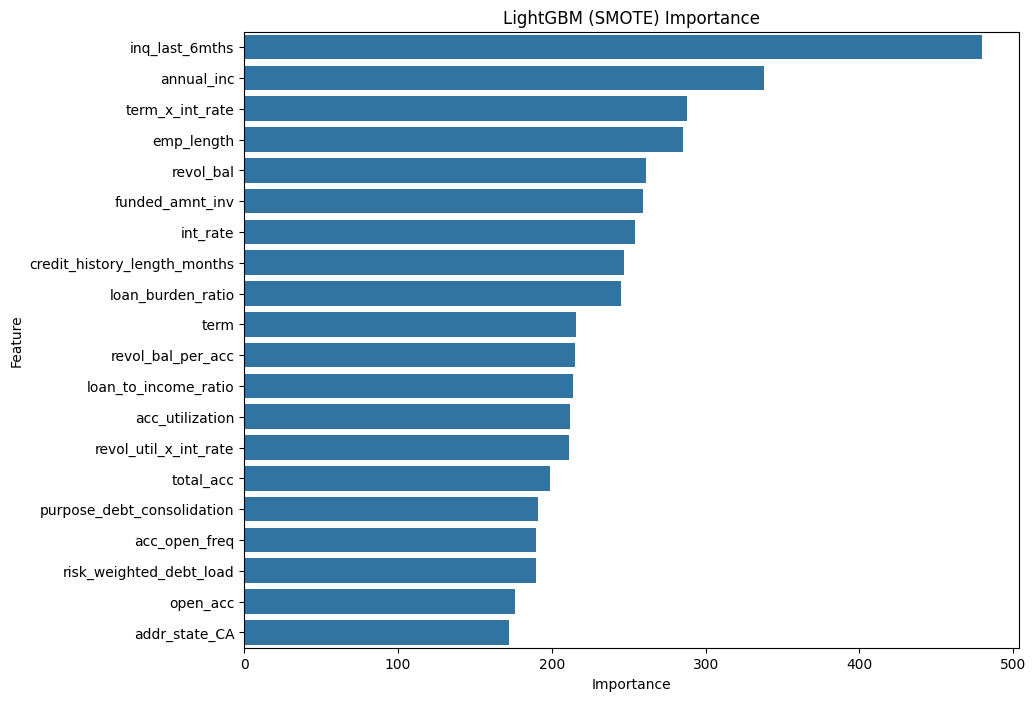

In [10]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, classification_report
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("LightGBM + Features + SMOTE")

#1. Load Data
df = pd.read_csv("Anonymize_Loan_Default_data.csv", encoding="latin1")

#2. Define Target and Fix Leaks
target = 'repay_fail'
y = df[target]
leaky_features = [
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'last_pymnt_amnt', 'last_pymnt_d',
    'loan_status'
]
cols_to_drop = [
    'Unnamed: 0', 'id', 'member_id', 'next_pymnt_d',
    'zip_code', 'issue_d',
    'last_credit_pull_d', 'earliest_cr_line'
] + leaky_features
all_cols_to_drop = [col for col in cols_to_drop if col in df.columns] + [target]
X = df.drop(columns=all_cols_to_drop)

#3. Feature Engineering & Cleaning (Batches 1-3)
print("Starting Preprocessing & Feature Engineering")
threshold = 0.4 * len(X)
X = X.dropna(thresh=threshold, axis=1)
X['term'] = X['term'].str.replace(' months', '').astype(float)
X['revol_util'] = X['revol_util'].astype(str).str.replace(r'[“%”]', '', regex=True).str.strip()
X['revol_util'] = pd.to_numeric(X['revol_util'], errors='coerce')
def clean_emp_length(text):
    if pd.isnull(text) or text == 'n/a': return np.nan
    if '< 1 year' in text: return 0.5
    if '10+ years' in text: return 10
    match = re.search(r'(\d+)', text)
    if match: return float(match.group(1))
    return np.nan
X['emp_length'] = X['emp_length'].apply(clean_emp_length)
print("Adding derived features (Batches 1, 2, 3)...")
earliest_cr_line_dt = pd.to_datetime(df['earliest_cr_line'], format='%b-%y', errors='coerce')
issue_d_dt = pd.to_datetime(df['issue_d'], format='%b-%y', errors='coerce')
X['credit_history_length_months'] = (issue_d_dt.dt.year * 12 + issue_d_dt.dt.month) - \
                                    (earliest_cr_line_dt.dt.year * 12 + earliest_cr_line_dt.dt.month)
X['credit_history_length_months'] = X['credit_history_length_months'].replace(0, 1)
X['annual_inc'] = X['annual_inc'].replace(0, np.nan)
X['loan_to_income_ratio'] = X['loan_amnt'] / X['annual_inc']
X['revol_bal_per_acc'] = np.where(X['open_acc'] > 0, X['revol_bal'] / X['open_acc'], 0)
X['acc_open_freq'] = np.where(X['credit_history_length_months'] > 0,
                              X['total_acc'] / X['credit_history_length_months'], 0)
X['loan_to_term'] = X['loan_amnt'] / X['term']
X['dti_x_int_rate'] = X['dti'] * X['int_rate']
X['inq_dti_interaction'] = X['inq_last_6mths'] * X['dti']
X['term_x_int_rate'] = X['term'] * X['int_rate']
X['acc_utilization'] = np.where(X['total_acc'] > 0, X['open_acc'] / X['total_acc'], 0)
X['loan_burden_ratio'] = X['installment'] / (X['annual_inc'] + 1e-6)
X['risk_weighted_debt_load'] = (X['dti'] * X['int_rate']) / (X['annual_inc'] + 1e-6)
X['credit_seeking_pressure'] = X['inq_last_6mths'] * X['acc_utilization']
X['revol_util_x_int_rate'] = X['revol_util'] * X['int_rate']

# 4. Preprocessing
if 'revol_util' in X.columns:
    X['revol_util'] = X['revol_util'].fillna(X['revol_util'].mode()[0])
if 'revol_bal' in X.columns:
    X['revol_bal'] = X['revol_bal'].fillna(X['revol_bal'].median())
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(X.median())
print(f"Final processed shape: {X.shape}")

#5. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

#6. Hyperparameter Tuning (with SMOTE Pipeline)
print(" Starting Hyperparameter Tuning (LightGBM + SMOTE)")

# Define Model (NO is_unbalance=True)
lgbm_model = LGBMClassifier(random_state=42, n_jobs=-1)

# Create the pipeline
smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', lgbm_model)
])

# Define the parameter grid
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7],
    'model__num_leaves': [15, 31, 50],
}

smote_search = RandomizedSearchCV(
    estimator=smote_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring='roc_auc', cv=3, verbose=1, n_jobs=-1, random_state=42
)
print("Fitting SMOTE pipeline...")
smote_search.fit(X_train, y_train)
print("Best SMOTE Pipeline Parameters:", smote_search.best_params_)
print(f"Best SMOTE Pipeline CV AUC: {smote_search.best_score_:.4f}")

#7. Final Evaluation
print("\n--- Final Model Evaluation (Test Set) ---")
best_smote_model = smote_search.best_estimator_
y_prob_lgbm = best_smote_model.predict_proba(X_test)[:,1]
y_pred_lgbm = best_smote_model.predict(X_test)
final_auc = roc_auc_score(y_test, y_prob_lgbm)
print(f"\n**Final LightGBM + SMOTE AUC: {final_auc:.4f}**")
print("LightGBM + SMOTE Classification Report:\n", classification_report(y_test, y_pred_lgbm))

#8. Feature Importance
print("\n--- Generating Feature Importance Plot ---")
final_model_from_pipeline = best_smote_model.named_steps['model']
importances = final_model_from_pipeline.feature_importances_
features = X_train.columns
imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False).head(20)
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=imp_df)
plt.title('LightGBM (SMOTE) Importance')
plt.savefig('lgbm_smote_importance.png', bbox_inches='tight')
plt.show()